# Conditional Normalizing Flow per Reaction-Advection-Diffusion
Idea:

$$
\mu=(c_1,c_2,c_3)
$$

are the velocities of the three cylinders.

For each $\mu$, a FOM trajectory is generated with random permeability. Then, a POD basis is constructed from the snapshots, and a conditional generative model is trained using flow matching:

$$
q(c(t)\mid \mu,t),
$$

where $c(t)$ are the POD coefficients of the snapshot $u(t)$.

During generation, one can sample a single latent noise vector $z$ and reuse it for all time steps. In this way, the generated trajectory is more temporally coherent than it would be if an independent noise sample were drawn at each time step.

## FOM baseline from Randomized advection diffusion

In [3]:
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*
import numpy as np
import matplotlib.pyplot as plt
clc()

In [4]:
# Domain and boundary conditions for Stokes problem (diffusion & transport for the fluid)
domain = fe.rectangle((0, 0), (3, 2))-fe.circle((0.95, 0.7), 0.25)-fe.circle((1.5, 1.35), 0.25)-fe.circle((2.05, 0.7), 0.25)
mesh = fe.mesh(domain, stepsize = 0.05)

left = lambda x: x[0]<1e-6
right = lambda x: 3-x[0]<1e-12
circle = lambda x0, r: (lambda x: ((x[0]-x0[0])**2 + (x[1]-x0[1])**2)**0.5 < r+1e-3)

def inflows(b0, b1, b2, b3):
  return [[left,                       lambda x: [b0*np.exp(-25*(x[1]-1)**2), 0.0]],
          [circle((0.95, 0.70), 0.25), lambda x: [b1*(-x[1]+0.70),    b1*(x[0]-0.95)]],
          [circle((1.50, 1.35), 0.25), lambda x: [b2*(-x[1]+1.35),    b2*(x[0]-1.50)]],
          [circle((2.05, 0.70), 0.25), lambda x: [b3*(-x[1]+0.70),    b3*(x[0]-2.05)]]]

outflows = [right]

In [5]:
# Solver for fluid problem
# Modified version of Stokes equation (Brinkman) in order to take care of impurities considered in the "permeability" spatial field
def brinkman_solver(mesh, inflows, outflows, permeability, source = [0.0, 0.0]):
  from fenics import FiniteElement, NodalEnrichedElement, FunctionSpace, VectorElement, TrialFunctions, TestFunctions
  from fenics import inner, grad, dx, div, assemble, DirichletBC, Constant, Expression
  from scipy.sparse.linalg import spsolve
  from scipy.sparse import csr_matrix

  pP1  = FiniteElement("CG", mesh.ufl_cell(), 1)
  vP1B = VectorElement(NodalEnrichedElement(FiniteElement("CG",       mesh.ufl_cell(), 1),
                                            FiniteElement("Bubble",   mesh.ufl_cell(), mesh.topology().dim() + 1)))

  pspace, vspace = pP1, vP1B
  W = FunctionSpace(mesh, vspace * pspace)
  W0 = FunctionSpace(mesh, vspace)
  (b, p) = TrialFunctions(W)
  (v, q) = TestFunctions(W)

  space = fe.space(mesh, "CG", 1, vector_valued = True, bubble = True)
  dspace = fe.space(mesh, "DG", 0)
  f = fe.interpolate(source, space)
  kappainv = fe.asfunction(1.0/permeability, dspace)
  a = inner(grad(b), grad(v))*dx - div(v)*p*dx - q*div(b)*dx + kappainv*inner(b, v)*dx
  L = inner(f, v)*dx

  def outflow(x):
    result = False
    for out in outflows:
      result = result or out(x)
    return result

  def inflow(x):
    result = False
    for infl in inflows:
      result = result or infl[0](x)
    return result

  def walls(x):
    return not(outflow(x) or inflow(x))

  noslip = DirichletBC(W.sub(0), Constant((0.0, 0.0)), lambda x, on: on and walls(x))
  def make_bc(i):
    return DirichletBC(W.sub(0), fe.interpolate(inflows[i][1], W0), lambda x, on: on and inflows[i][0](x))
  ins = [make_bc(i) for i in range(len(inflows))]

  A = assemble(a)
  F = assemble(L)

  for bc in [noslip, *ins]:
    bc.apply(A)
    bc.apply(F)

  A = csr_matrix(A.array())
  F = F[:]

  bp = spsolve(A, F)
  bp_f = fe.asfunction(bp, W)

  from fenics import dof_to_vertex_map
  Vh = fe.space(mesh,'CG', 1)
  Vb = fe.space(mesh,'CG', 1, vector_valued = True)
  nvertices = mesh.coordinates().shape[0]
  b = bp_f.compute_vertex_values(mesh)[:2*nvertices].reshape(2, -1).T
  indexes = dof_to_vertex_map(Vh)
  b = b[indexes].reshape(-1)
  return b

In [6]:
# Solver per l'equazione di diffusione-trasporto time dependent
Vh = fe.space(mesh, 'CG', 1)
Vb = fe.space(mesh, 'CG', 1, vector_valued = True)
Dh = fe.space(mesh, 'DG', 0)
clc()

from fenics import dx
M = fe.assemble(lambda u, v: u*v*dx, Vh)

def steadyFOMsolver(mu, permeability, dt, u0, b):
  # Solver stazionario: utilizzato per lo step di Eulero backward
  from fenics import grad, inner, solve, TrialFunction, TestFunction, Function, Constant, DirichletBC, assemble
  from scipy.sparse.linalg import spsolve

  def a(u, v):
    return Constant(dt*0.005)*inner(grad(u), grad(v))*dx + Constant(dt)*inner(b, grad(u))*v*dx + inner(u, v)*dx

  A = fe.assemble(a, Vh)
  F = M @ u0
  bc = fe.DirichletBC(left, lambda x: np.exp(-25*(x[1]-1)**2))
  A = fe.applyBCs(A, Vh, bc)
  F = fe.applyBCs(F, Vh, bc)
  u = spsolve(A, F)
  clc()
  return u

def FOMsolver(mu, permeability, dt=1e-3, u0 = np.zeros(Vh.dim()), steps = 50):
  # Solver temporale
  u = [u0]
  b = fe.asfunction(brinkman_solver(mesh, inflows(1.0, *mu), outflows, permeability), Vb) # soluzione del problema fluido
  for i in range(steps):
    u.append(steadyFOMsolver(mu, permeability, dt, u[-1], b))
  return np.stack(u)

In [7]:
# Funzione ausiliaria per samplare impurità nel dominio
rho = 0.1 # dimensione (raggio) delle impurità
boundary = mesh.coordinates()[fe.boundary(mesh)]

def sample_impurity():
  # sampling con acceptance-rejection
  found = False
  while(not found):
    candidate = np.random.uniform(low = (0, 0), high = (3, 2), size = (2,))
    dist = np.linalg.norm(boundary- candidate.reshape(1, 2), axis = -1).min()
    found = dist > rho
  return candidate

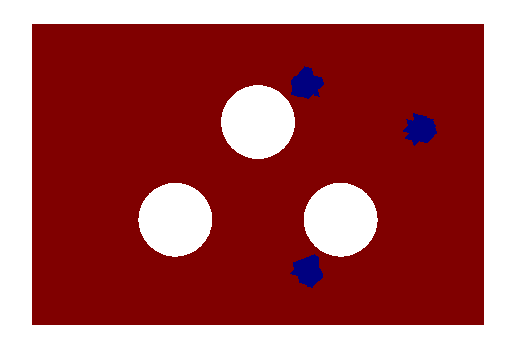

In [8]:
def sample_permeability(nimp):
  # Sampling di "nimp" impurità e calcolo del rispettivo campo di permeabilità per il fluido
  impurities = np.stack([sample_impurity() for i in range(nimp)])
  xdofs = fe.dofs(Dh)
  distances = np.linalg.norm(xdofs.reshape(-1, 1, 2)-impurities.reshape(1, -1, 2), axis = -1).min(axis = 1)
  permeability = 1000*np.ones(Dh.dim())
  permeability[distances<rho] = 0.001
  return permeability

fe.plot(sample_permeability(3), Dh) # esempio di campo di permeabilità con 3 impurità

## 1. Experiment configuration roadmap
In this first scenario, 200 different values of the parameter $\mu=(c_1,c_2,c_3)$ are generated, together with one random permeability realization for each $\mu$.
We take into account 101 time instants for each trajectory, because steps = 100 implies $100+1$ snapshots.

The idea here is first to sample many values of $\mu$ and then to solve the full order model for each of them.

In [9]:
PROFILE = "roadmap"

PROFILES = {

    # Profilo roadmap: usa 200 parametri mu e 1 realizzazione per ciascun parametro
    "roadmap": dict(n_mu=200, n_realizations=1, nimp=5, dt=5e-2, steps=100, seed=1),

    # Profilo fixed: usa 1 parametro mu e 1 realizzazione per ciascun parametro
    "fixed": dict(n_mu=1, n_realizations=100, nimp=3, dt=5e-2, steps=100, seed=1),
    }

cfg = PROFILES[PROFILE]

cfg


{'n_mu': 200,
 'n_realizations': 1,
 'nimp': 5,
 'dt': 0.05,
 'steps': 100,
 'seed': 1}

In [10]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import os
import numpy as np

EXP_NAME = (
    f"rad_{cfg['n_mu']}mu_"
    f"{cfg['n_realizations']}real_"
    f"nimp{cfg['nimp']}_"
    f"dt{cfg['dt']}_"
    f"steps{cfg['steps']}_"
    f"seed{cfg['seed']}"
)
SAVE_DIR = f"/content/drive/MyDrive/RAD_flow_project/{EXP_NAME}"

os.makedirs(SAVE_DIR, exist_ok=True)
fom_dataset_path = os.path.join(SAVE_DIR, f"fom_dataset_{EXP_NAME}.npz")
model_path = os.path.join(SAVE_DIR, f"conditional_realnvp_{EXP_NAME}_r{r}.pt")


## 2. Sampling of $\mu$ and construction of the FOM dataset

This section is based on sampling $N_\mu$ parameters

$$
\mu_i=(c_{1,i},c_{2,i},c_{3,i}),
$$

which are needed to solve the high-fidelity model for each parameter and collect the trajectories produced by the solver.

For each $\mu_i$, the full order model returns a trajectory:

$$
U_i = \left[u_i(t_0),u_i(t_1),\ldots,u_i(t_{12})\right],
$$

where each snapshot $u_i(t_j)$ belongs to a space of dimension $N_h=2763$.


In [32]:
# Defines a function to randomly sample the physical parameter mu
def sample_mu(low=-6.0, high=6.0):
    # Draws three independent components uniformly in the interval [low, high)
    return np.random.uniform(low=low, high=high, size=(3,))


# Defines the function that builds the FOM dataset from the chosen configuration
def build_fom_dataset(n_mu, n_realizations, nimp, dt, steps, seed=None):

    if seed is not None:
        np.random.seed(seed)

    # Generates a stack of n_mu different mu parameters, each with three components
    mu_bank = np.stack([sample_mu() for _ in range(n_mu)])

    # conds = mu parameters associated to each trajectory
    conds = []

    # trajectories produced by the full order model
    trajectories = []

    # Each group corresponds to one value of mu -> set of group identifiers
    group_ids = []

    for i, mu in enumerate(mu_bank):

        for r in range(n_realizations):

            # Samples a random permeability field
            permeability = sample_permeability(nimp)

            # The output U is a complete trajectory with shape:
            # (number of time steps, degrees of freedom)
            U = FOMsolver(mu, permeability, dt=dt, steps=steps)

            # Stores the mu parameter associated with the current trajectory
            conds.append(mu.copy())

            # Stores the trajectory produced by the solver
            trajectories.append(U)

            # Stores the group index, useful for retrieving all trajectories with the same mu
            group_ids.append(i)

            # Progress of the FOM dataset construction
            print(
                f"mu {i+1:3d}/{n_mu}, "
                f"realizzazione {r+1:2d}/{n_realizations}, "
                f"U.shape={U.shape}"
            )

    # Physical time grid: t_0=0, t_1=dt, ..., t_steps=steps*dt
    times = np.arange(steps + 1) * dt

    # Returns all dataset objects as NumPy arrays
    return (
        mu_bank,
        times,
        np.stack(conds),
        np.stack(trajectories),
        np.array(group_ids),
    )


# If the FOM dataset has already been computed, load it from disk.
# Otherwise, compute it and save it for future runs.
if os.path.exists(fom_dataset_path):
    data = np.load(fom_dataset_path)

    mu_bank = data["mu_bank"]
    times = data["times"]
    conds = data["conds"]
    trajectories = data["trajectories"]
    group_ids = data["group_ids"]

else:
    mu_bank, times, conds, trajectories, group_ids = build_fom_dataset(**cfg)

    np.savez_compressed(
        fom_dataset_path,
        mu_bank=mu_bank,
        times=times,
        conds=conds,
        trajectories=trajectories,
        group_ids=group_ids,
    )

print("mu_bank shape      :", mu_bank.shape)
print("times shape        :", times.shape)
print("conds shape        :", conds.shape)
print("trajectories shape :", trajectories.shape)
print("group_ids shape    :", group_ids.shape)

mu_bank shape      : (200, 3)
times shape        : (101,)
conds shape        : (200, 3)
trajectories shape : (200, 101, 2763)
group_ids shape    : (200,)


## 3. POD on the snapshots

This section constructs a reduced basis from the FOM snapshots.

All trajectories are transformed into a snapshot matrix:

$$
X_{\text{snapshot}}\in \mathbb{R}^{20200\times 2763},
$$

because there are 200 trajectories and 101 time steps:

$$
200\cdot 101=20200.
$$

POD is applied to the centered snapshots, that is, after subtracting the mean field.

In this way, each snapshot $u(t)$ is represented through a small number of POD coefficients:

$$
u(t)-\bar u \approx \sum_{k=1}^{r} c_k(t)\phi_k.
$$

Here, I retain $r=30$ POD modes, since they explain approximately 98.98% of the total energy.


In [33]:
# Defines the POD configuration
# The number of modes is first selected using the cumulative energy criterion
# The reconstruction and sliced-Wasserstein diagnostics are then used as an additional check
POD_CFG = dict(
    energy=0.999,
    min_modes=4,
    max_modes=30,
)

# Reads the dimensions of the trajectory tensor.
# Ntraj = number of trajectories, Nt = number of time steps, Vdim = spatial dimension.
Ntraj, Nt, Vdim = trajectories.shape

# Flattens the trajectories into a snapshot matrix.
# Each row is one snapshot u(t), regardless of the trajectory it comes from.
snapshots = trajectories.reshape(Ntraj * Nt, Vdim)

# Computes the mean field over all snapshots, component by component.
field_mean = snapshots.mean(axis=0, keepdims=True)

# Centers the snapshots by subtracting the mean field.
snapshots_c = snapshots - field_mean

# Performs the SVD of the centered snapshot matrix to extract the POD modes.
U_svd, S_svd, Vt_svd = np.linalg.svd(snapshots_c, full_matrices=False)

# Computes the cumulative energy explained by the singular values.
energy = np.cumsum(S_svd**2) / np.sum(S_svd**2)

# Finds the first number of modes that exceeds the required energy threshold.
r_auto = int(np.searchsorted(energy, POD_CFG["energy"]) + 1)

# Restricts the number of modes between the prescribed minimum and maximum values.
r = min(max(r_auto, POD_CFG["min_modes"]), POD_CFG["max_modes"])

# Selects the first r POD modes.
basis = Vt_svd[:r]

# Projects all centered snapshots onto the selected POD basis
# C_snap contains the POD coefficients of each snapshot
C_snap = snapshots_c @ basis.T

# Reshapes the POD coefficients into trajectory-time-mode format
# C_traj[i, j, :] contains the POD coefficients of trajectory i at time step j
C_traj = C_snap.reshape(Ntraj, Nt, r)

# Reconstructs all snapshots using the selected POD basis
snapshots_rec = field_mean + C_snap @ basis

# Computes the relative L2 reconstruction error of the POD approximation
pod_l2_rel_error = np.linalg.norm(snapshots - snapshots_rec) / (
    np.linalg.norm(snapshots) + 1e-12
)

# Computes the absolute L2 reconstruction error
pod_l2_abs_error = np.linalg.norm(snapshots - snapshots_rec)
print(f"POD relative L2 reconstruction error: {pod_l2_rel_error:.4e}")
print(f"POD absolute L2 reconstruction error: {pod_l2_abs_error:.4e}")


print("snapshots shape:", snapshots.shape)
print("basis shape    :", basis.shape)
print("C_snap shape   :", C_snap.shape)
print("C_traj shape   :", C_traj.shape)
print(f"Energy explained by first {r} modes: {energy[r-1]:.4f}")


POD relative L2 reconstruction error: 5.5108e-02
POD absolute L2 reconstruction error: 1.0382e+02
snapshots shape: (20200, 2763)
basis shape    : (30, 2763)
C_snap shape   : (20200, 30)
C_traj shape   : (200, 101, 30)
Energy explained by first 30 modes: 0.9898


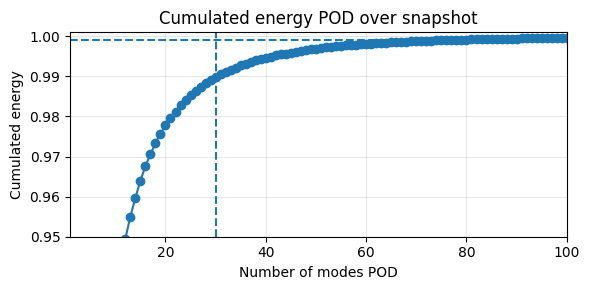

In [34]:
from IPython.display import display

fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(np.arange(1, len(energy) + 1), energy, marker="o")
ax.axhline(POD_CFG["energy"], linestyle="--")
ax.axvline(r, linestyle="--")

ax.set_xlim(1, 100)
ax.set_ylim(0.95, 1.001)

ax.set_xlabel("Number of modes POD")
ax.set_ylabel("Cumulated energy")
ax.set_title("Cumulated energy POD over snapshot")
ax.grid(True, alpha=0.3)

fig.tight_layout()
display(fig)
plt.close(fig)


### Additional diagnostics for selecting the number of POD modes

In addition to the cumulative energy criterion, we introduce two relative error measures to directly evaluate the quality of the POD reconstruction in the physical space. The goal is to check how well the projection onto the first $k$ POD modes approximates the original snapshots.

For each candidate number of modes $k$, we reconstruct the snapshots as

$u_j^{(i)} \approx VV^T u_j^{(i)},$

where $V$ contains the first $k$ POD modes. In the notebook, the reconstruction is performed by projecting the centered snapshots onto the POD basis and then adding back the mean field.

The first measure is the average relative error computed snapshot by snapshot:

$\frac{1}{N_s N_t}\sum_{i=1}^{N_s}\sum_{j=1}^{N_t}
\frac{\|u_j^{(i)} - VV^T u_j^{(i)}\|}{\|u_j^{(i)}\|}.$

This metric assigns the same weight to each snapshot in the dataset.

The second measure is the average relative error computed trajectory by trajectory:

$\frac{1}{N_s}\sum_{i=1}^{N_s}
\frac{\sum_{j=1}^{N_t}\|u_j^{(i)} - VV^T u_j^{(i)}\|}
{\sum_{j=1}^{N_t}\|u_j^{(i)}\|}.$

This metric assigns the same weight to each trajectory, because the error is first aggregated over time and then averaged over the different realizations.


In [16]:
# POD and error computation

Uh = trajectories.reshape(Ntraj * Nt, Vdim)
Uh_mean = Uh.mean(axis=0, keepdims=True)
Uh_c = Uh - Uh_mean
_, sigma, Vt = np.linalg.svd(Uh_c, full_matrices=False)

errors_1 = []
errors_2 = []

for n in range(1,100):
  #n = 30
  Un = Uh @ Vt[:n].T
  Uh_rec =  (Un @ Vt[:n]).reshape(Ntraj, Nt, Vdim)
  Uh_rec += Uh_mean
  Uh_rec.shape
  num = np.linalg.norm(trajectories - Uh_rec, axis=-1)
  den = np.linalg.norm(trajectories, axis=-1)

  error_1 = np.mean(num / (den + 1e-12))
  error_2 = np.mean(np.sum(num, axis=-1) / (np.sum(den, axis=-1) + 1e-12))

  #print(n, error_1, error_2)

  errors_1.append(error_1)
  errors_2.append(error_2)

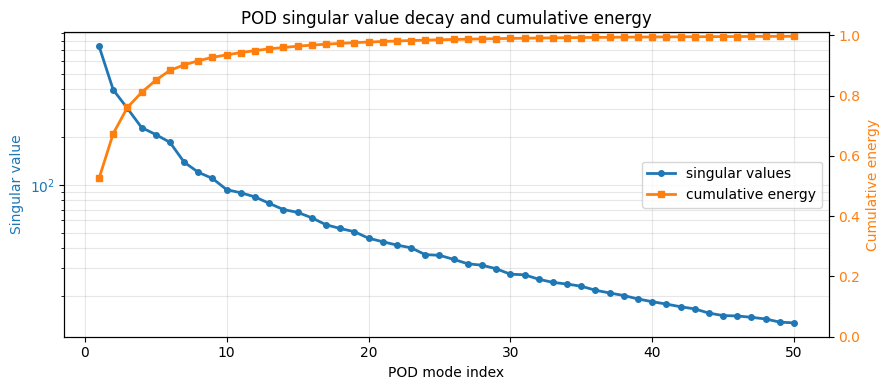

In [35]:
from IPython.display import display

n_show = 50
modes = np.arange(1, n_show + 1)

energy_sigma = np.cumsum(sigma**2) / np.sum(sigma**2)

fig, ax1 = plt.subplots(figsize=(9, 4))

ax1.semilogy(
    modes,
    sigma[:n_show],
    marker="o",
    markersize=4,
    linewidth=2,
    color="tab:blue",
    label="singular values",
)

ax1.set_xlabel("POD mode index")
ax1.set_ylabel("Singular value", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3, which="both")

ax2 = ax1.twinx()

ax2.plot(
    modes,
    energy_sigma[:n_show],
    marker="s",
    markersize=4,
    linewidth=2,
    color="tab:orange",
    label="cumulative energy",
)

ax2.set_ylabel("Cumulative energy", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.set_ylim(0.0, 1.01)

ax1.set_title("POD singular value decay and cumulative energy")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="center right",
)

fig.tight_layout()
display(fig)
plt.close(fig)

In [36]:
# POD and error computation

Uh = trajectories.reshape(Ntraj * Nt, Vdim)
Uh_mean = Uh.mean(axis=0, keepdims=True)
Uh_c = Uh - Uh_mean

_, sigma, Vt = np.linalg.svd(Uh_c, full_matrices=False)

errors_1 = []
errors_2 = []
global_errors = []
energy_values = []

for n in range(1, 101):

    # Project centered snapshots onto the first n POD modes
    Un = Uh_c @ Vt[:n].T

    # Reconstruct centered snapshots and add back the mean
    Uh_rec = Un @ Vt[:n] + Uh_mean

    # Reshape back to trajectory format
    Uh_rec = Uh_rec.reshape(Ntraj, Nt, Vdim)

    # Pointwise-in-time L2 error
    num = np.linalg.norm(trajectories - Uh_rec, axis=-1)
    den = np.linalg.norm(trajectories, axis=-1)

    # Error 1: average relative error snapshot by snapshot
    error_1 = np.mean(num / (den + 1e-12))

    # Error 2: trajectory-wise relative error, then averaged over trajectories
    error_2 = np.mean(
        np.sum(num, axis=-1) / (np.sum(den, axis=-1) + 1e-12)
    )

    # Global relative Frobenius reconstruction error
    global_error = np.linalg.norm(
        trajectories.reshape(Ntraj * Nt, Vdim) - Uh_rec.reshape(Ntraj * Nt, Vdim)
    ) / (np.linalg.norm(Uh) + 1e-12)

    # Cumulative POD energy
    energy_n = np.sum(sigma[:n] ** 2) / np.sum(sigma ** 2)

    errors_1.append(error_1)
    errors_2.append(error_2)
    global_errors.append(global_error)
    energy_values.append(energy_n)

errors_1 = np.array(errors_1)
errors_2 = np.array(errors_2)
global_errors = np.array(global_errors)
energy_values = np.array(energy_values)

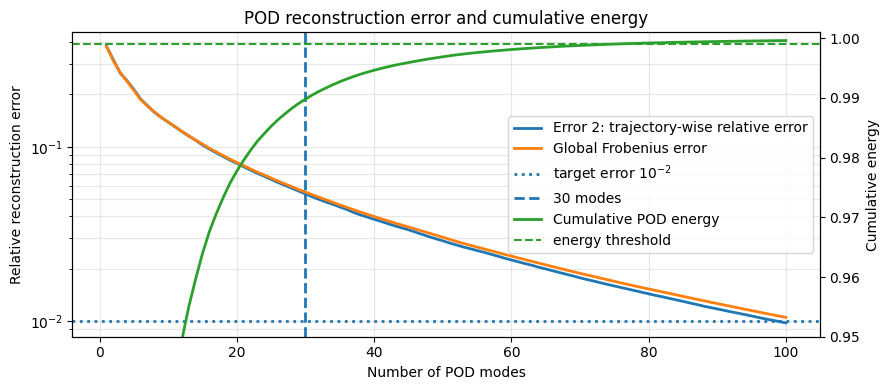

In [37]:
from IPython.display import display

modes = np.arange(1, len(errors_2) + 1)

fig, ax1 = plt.subplots(figsize=(9, 4))

# Plot only the interpretable reconstruction errors
ax1.semilogy(
    modes,
    errors_2,
    linewidth=2,
    label="Error 2: trajectory-wise relative error",
)

ax1.semilogy(
    modes,
    global_errors,
    linewidth=2,
    label="Global Frobenius error",
)

# Optional target line
ax1.axhline(
    1e-2,
    linestyle=":",
    linewidth=2,
    label=r"target error $10^{-2}$",
)

# Highlight 30 modes
ax1.axvline(
    30,
    linestyle="--",
    linewidth=2,
    label="30 modes",
)

ax1.set_xlabel("Number of POD modes")
ax1.set_ylabel("Relative reconstruction error")
ax1.set_title("POD reconstruction error and cumulative energy")
ax1.grid(True, alpha=0.3, which="both")

# Second axis for cumulative energy
ax2 = ax1.twinx()

ax2.plot(
    modes,
    energy_values,
    color="C2",
    linewidth=2,
    label="Cumulative POD energy",
)

ax2.axhline(
    0.999,
    color="C2",
    linestyle="--",
    linewidth=1.5,
    label="energy threshold",
)

ax2.set_ylabel("Cumulative energy")
ax2.set_ylim(0.95, 1.001)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="center right",
)

fig.tight_layout()
display(fig)
plt.close(fig)

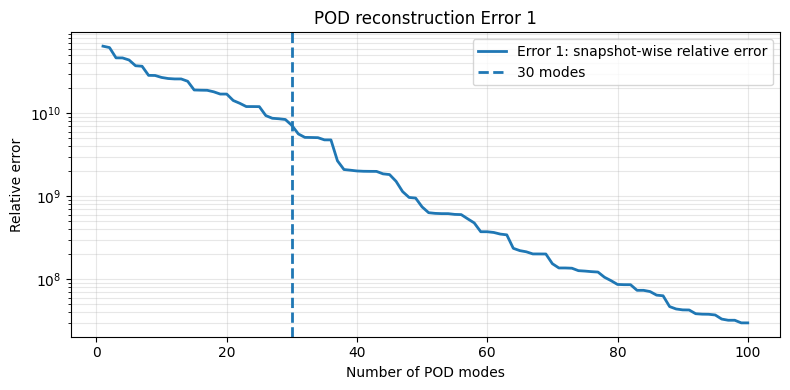

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.semilogy(
    modes,
    errors_1,
    linewidth=2,
    label="Error 1: snapshot-wise relative error",
)

ax.axvline(30, linestyle="--", linewidth=2, label="30 modes")

ax.set_xlabel("Number of POD modes")
ax.set_ylabel("Relative error")
ax.set_title("POD reconstruction Error 1")
ax.grid(True, alpha=0.3, which="both")
ax.legend()

fig.tight_layout()
display(fig)
plt.close(fig)

## 4. Dataset for the conditional normalizing flow

This section constructs the dataset used to train the conditional normalizing flow.

I want to learn a relation of the form:

$$
(\mu,t)\longmapsto c(t),
$$

where $c(t)$ is the vector of POD coefficients of the snapshot at time $t$.

Therefore, the input of the model is:

$$
X_{\text{cond}}=(\mu_1,\mu_2,\mu_3,t_{\text{norm}})\in\mathbb{R}^4,
$$

while the output modeled by the flow is:

$$
Y_{\text{coeff}}=c(t)\in\mathbb{R}^{100}.
$$

Time is normalized to the interval $[0,1]$, because the neural network works better when the inputs have comparable scales.


In [38]:
# Target reconstruction error
target_error = 1e-2

# Finds the first number of modes such that Error 1 is below the target
valid_idx = np.where(errors_2 <= target_error)[0]

if len(valid_idx) > 0:
    r_error = int(valid_idx[0] + 1)
else:
    r_error = len(errors_1)
    print(f"No mode number reaches Error 1 <= {target_error:.1e}; using the maximum tested r = {r_error}")

# Updates the POD dimension
r = r_error

# Rebuilds the POD basis using the selected number of modes
basis = Vt_svd[:r]

# Recomputes POD coefficients with the selected number of modes
C_snap = snapshots_c @ basis.T

# Reshapes POD coefficients into trajectory-time-mode format
C_traj = C_snap.reshape(Ntraj, Nt, r)

print(f"Selected r from Error 2 criterion: {r}")
print(f"Error 1 at r={r}: {errors_1[r-1]:.4e}")
print(f"Error 2 at r={r}: {errors_2[r-1]:.4e}")
print(f"Energy at r={r}: {energy[r-1]:.4f}")

# Repeats each mu parameter for all available physical time steps
# in order to associate every snapshot with the mu parameter of its trajectory
mu_snap = np.repeat(conds, Nt, axis=0)

# Repeats the time vector for all trajectories
t_snap = np.tile(times, Ntraj).reshape(-1, 1)

# Normalizes time in [0, 1]
t_snap_norm = t_snap / times[-1]

# Builds the condition matrix by concatenating mu and normalized time
X_cond = np.concatenate([mu_snap, t_snap_norm], axis=1)

# The target of the conditional model is the POD coefficient vector
# with dimension equal to the selected r
Y_coeff = C_snap

print("X_cond shape:", X_cond.shape)
print("Y_coeff shape:", Y_coeff.shape)

Selected r from Error 2 criterion: 99
Error 1 at r=99: 2.9845e+07
Error 2 at r=99: 9.9900e-03
Energy at r=99: 0.9996
X_cond shape: (20200, 4)
Y_coeff shape: (20200, 99)


## 5. Normalization and train/validation split

Before training the normalizing flow, I normalize both the conditioning variables and the POD coefficients, because $\mu$, time and POD coefficients may have different numerical scales.

Then, I split the dataset into training and validation sets. In this setting, there are 20200 samples, of which 16160 are used for training and 4040 for validation.


In [39]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split

# Defines a standard normalizer for NumPy arrays
class ArrayNormalizer:

    def fit(self, x):
        self.mean = x.mean(axis=0, keepdims=True)
        self.std = x.std(axis=0, keepdims=True) + 1e-6
        return self

    def transform(self, x):
        return (x - self.mean) / self.std # Standard normalization

    def inverse(self, x):
        return x * self.std + self.mean # Back to original one


# Fits a normalizer to the condition matrix X_con and to the POD coefficient matrix Y_coeff
cond_norm = ArrayNormalizer().fit(X_cond)
coeff_norm = ArrayNormalizer().fit(Y_coeff)

# Normalizes the conditions and POD coefficients and converts them to a float32 PyTorch tensor
Xn = torch.tensor(cond_norm.transform(X_cond), dtype=torch.float32)
Yn = torch.tensor(coeff_norm.transform(Y_coeff), dtype=torch.float32)

# Builds a PyTorch dataset that pairs each condition with its POD target
dataset = TensorDataset(Xn, Yn)

# Computes the number of training samples, equal to 80% of the entire dataset
n_train = int(0.8 * len(dataset))

# Computes the number of validation samples
n_val = len(dataset) - n_train

# Splits the dataset into training and validation sets in a reproducible way
train_ds, val_ds = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(0),
)

print("train samples:", len(train_ds))
print("val samples  :", len(val_ds))

train samples: 16160
val samples  : 4040


## 6. Conditional RealNVP

This section defines the conditional generative model. The model is a **conditional normalizing flow** based on RealNVP.

In this model, an invertible transformation is learned between

$$
z\sim \mathcal{N}(0,I)
$$

and the POD coefficients

$$
c(t)\mid(\mu,t).
$$

Therefore, the model directly approximates the conditional density

$$
q(c(t)\mid \mu,t).
$$

The advantage is that the normalizing flow allows us to compute an explicit log-likelihood.


In [40]:
class AffineCoupling(nn.Module):
    # Initializes the layer with target dimension, condition dimension and mask
    def __init__(self, dim_y, dim_cond, mask, hidden_size=128, hidden_depth=2):

        super().__init__() #initialize Pytorch base class
        self.register_buffer("mask", mask)

        # Creates the first layers of the internal coupling network
        layers = [
            nn.Linear(dim_y + dim_cond, hidden_size),
            nn.SiLU(),
        ]

        # Adds hidden_depth linear blocks with SiLU activation
        for _ in range(hidden_depth):
            layers += [
                nn.Linear(hidden_size, hidden_size),
                nn.SiLU(),
            ]

        # The final layer outputs both shift and log-scale, so its dimension is 2*dim_y
        layers.append(nn.Linear(hidden_size, 2 * dim_y))

        # Builds the internal network as a sequential module
        self.net = nn.Sequential(*layers)

    # Defines the forward or inverse transformation of the coupling layer
    def forward(self, y, cond, log_det, reverse=False):

        y_masked = y * self.mask # Applies the mask: one subset of components remains unchanged

        h = torch.cat([y_masked, cond], dim=1) # Concatenates the masked part of the target with the condition

        shift, log_scale = self.net(h).chunk(2, dim=1) # The network is able to predictr both shift and log-scale

        # Bounds the log-scale with tanh and applies it only to the unmasked components
        log_scale = torch.tanh(log_scale) * (1.0 - self.mask)

        # Applies the shift only to the unmasked components
        shift = shift * (1.0 - self.mask)

        # Forward direction: maps normalized POD coefficients to the latent variable z
        if not reverse:
            y = y_masked + (1.0 - self.mask) * (y * torch.exp(log_scale) + shift)
            log_det = log_det + log_scale.sum(dim=1)

        # Reverse direction: maps latent noise z to generated POD coefficients
        else:
            y = y_masked + (1.0 - self.mask) * ((y - shift) * torch.exp(-log_scale))
            log_det = log_det - log_scale.sum(dim=1)

        # Returns the transformed vector and the updated log-determinant
        return y, log_det


class ConditionalRealNVP(nn.Module): # Full Conditional Normalizing Flow

    def __init__(self, dim_cond, dim_y, n_layers=8, hidden_size=128, hidden_depth=2): # composition of multiple coupling layers

        super().__init__()

        self.dim_cond = dim_cond # stores the condition dimension
        self.dim_y = dim_y # dimension of generated taget stored here

        # Builds alternating masks so that different components are transformed across layers
        masks = []
        for k in range(n_layers):
            mask_np = np.array([(i + k) % 2 for i in range(dim_y)], dtype=np.float32)
            masks.append(torch.tensor(mask_np).view(1, dim_y))

        # Creates the list of coupling layers
        self.layers = nn.ModuleList([
            AffineCoupling(dim_y, dim_cond, mask, hidden_size, hidden_depth)
            for mask in masks
        ])

    # Encodes y into z and computes the log-determinant of the transformation

    def encode(self, y, cond):
        # Initializes the log-determinant to zero for each element in the batch
        log_det = torch.zeros(y.shape[0], device=y.device)

        # Starts from the POD coefficient vector y
        z = y

        # Applies all coupling layers in the forward direction
        for layer in self.layers:
            z, log_det = layer(z, cond, log_det, reverse=False)

        # Returns the latent variable z and the log-determinant
        return z, log_det

    # Decodes z into y using the inverse transformation

    def decode(self, z, cond):
        # Initializes the log-determinant to zero
        log_det = torch.zeros(z.shape[0], device=z.device)

        # Starts from the latent noise z
        y = z

        # Applies the coupling layers in reverse order
        for layer in reversed(self.layers):
            y, log_det = layer(y, cond, log_det, reverse=True)

        # Returns the generated POD coefficients
        return y

    # Computes the log-probability of target y given condition
    def log_prob(self, y, cond):

        z, log_det = self.encode(y, cond) # Maps y to the latent variable z

        # Computes the standard Gaussian log-density of z
        log_pz = -0.5 * z.pow(2).sum(dim=1)
        log_pz = log_pz - 0.5 * self.dim_y * np.log(2.0 * np.pi)

        return log_pz + log_det  # change of variables formula: log p(y|cond)=log p(z)+log_det

    # Disables gradient tracking during sampling
    @torch.no_grad()

    # Generates conditional POD coefficients

    def sample(self, cond, z=None):
        # If z is not provided, samples standard Gaussian noise
        if z is None:
            z = torch.randn(cond.shape[0], self.dim_y, device=cond.device)

        # Decodes the noise into conditional POD coefficients
        return self.decode(z, cond)


## 7. Training of the conditional normalizing flow

This section trains the model by maximizing the conditional likelihood, or equivalently by minimizing the negative log-likelihood:

$$
\mathcal{L}=-\log p_\theta(c(t)\mid \mu,t).
$$

Here, the model learns the distribution of the POD coefficients at a fixed time, conditioned on $\mu$ and on the physical time.

In [41]:
# Defines hyperparameters of the normalizing flow
NF_CFG = dict(
    n_layers=8,
    hidden_size=128,
    hidden_depth=2,
    batch_size=128,
    epochs=300,
    lr=1e-3,
    weight_decay=1e-5,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

if os.path.exists(model_path):

    checkpoint = torch.load(model_path, map_location=device)

    NF_CFG = checkpoint["NF_CFG"]

    model = ConditionalRealNVP(
        dim_cond=checkpoint["dim_cond"],
        dim_y=checkpoint["dim_y"],
        n_layers=NF_CFG["n_layers"],
        hidden_size=NF_CFG["hidden_size"],
        hidden_depth=NF_CFG["hidden_depth"],
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    train_history = checkpoint["train_history"]
    val_history = checkpoint["val_history"]

    print("Loaded trained model from disk:")
    print(model_path)

else:

    # Builds the Conditional RealNVP model
    model = ConditionalRealNVP(
        dim_cond=Xn.shape[1],
        dim_y=Yn.shape[1],
        n_layers=NF_CFG["n_layers"],
        hidden_size=NF_CFG["hidden_size"],
        hidden_depth=NF_CFG["hidden_depth"],
    ).to(device)

    # Creates the training DataLoader
    train_loader = DataLoader(
        train_ds,
        batch_size=min(NF_CFG["batch_size"], len(train_ds)),
        shuffle=True,
        drop_last=False,
    )

    # Creates the validation DataLoader
    val_loader = DataLoader(
        val_ds,
        batch_size=min(NF_CFG["batch_size"], len(val_ds)),
        shuffle=False,
        drop_last=False,
    )

    # Defines the AdamW optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=NF_CFG["lr"],
        weight_decay=NF_CFG["weight_decay"],
    )

    train_history = []
    val_history = []

    # Loops over the training epochs
    for ep in range(NF_CFG["epochs"]):

        model.train()
        batch_losses = []

        for cond_b, coeff_b in train_loader:
            cond_b = cond_b.to(device)
            coeff_b = coeff_b.to(device)

            loss = -model.log_prob(coeff_b, cond_b).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for cond_b, coeff_b in val_loader:
                cond_b = cond_b.to(device)
                coeff_b = coeff_b.to(device)

                val_loss = -model.log_prob(coeff_b, cond_b).mean()
                val_losses.append(val_loss.item())

        train_history.append(float(np.mean(batch_losses)))
        val_history.append(float(np.mean(val_losses)))

        if (ep + 1) % max(1, NF_CFG["epochs"] // 10) == 0:
            print(
                f"epoca {ep+1:4d}/{NF_CFG['epochs']} - "
                f"train NLL={train_history[-1]:.4f} - "
                f"val NLL={val_history[-1]:.4f}"
            )

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "NF_CFG": NF_CFG,
            "train_history": train_history,
            "val_history": val_history,
            "dim_cond": Xn.shape[1],
            "dim_y": Yn.shape[1],
        },
        model_path,
    )


Loaded trained model from disk:
/content/drive/MyDrive/RAD_flow_project/rad_200mu_1real_nimp5_dt0.05_steps100_seed1/conditional_realnvp_rad_200mu_1real_nimp5_dt0.05_steps100_seed1_r99.pt


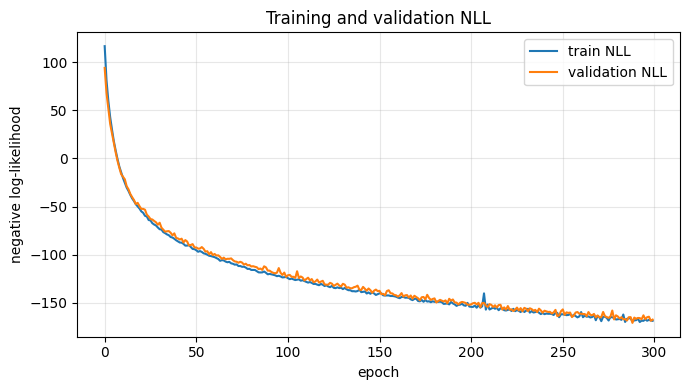

In [42]:
from IPython.display import display

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(train_history, label="train NLL")
ax.plot(val_history, label="validation NLL")

ax.set_xlabel("epoch")
ax.set_ylabel("negative log-likelihood")
ax.set_title("Training and validation NLL")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
display(fig)
plt.close(fig)


## 8. Temporal sampling: same $z$ for all time steps

The idea is: once a parameter $\mu$ is chosen, the conditioning inputs are built as

$$
(\mu,t_0),(\mu,t_1),\ldots,(\mu,t_{12}),
$$

and one POD coefficient vector is generated for each time step.

The important point is the comparison between two strategies:

1. using the same $z$ for all time steps;
2. using an independent $z$ at each time step.

Using the same $z$ means trying to represent the same random realization along the whole trajectory.

Therefore, it is a simple way to obtain greater temporal coherence, while still working with a model based on conditionally generated snapshots.


In [43]:
def build_conditions_for_mu(mu, times):

    mu_rep = np.repeat(mu.reshape(1, -1), len(times), axis=0)  # repeats the same mu for all time steps
    t_norm = (times / times[-1]).reshape(-1, 1) # normalizes the time values with respect to the final time

    return np.concatenate([mu_rep, t_norm], axis=1)

@torch.no_grad()

# Generates a POD trajectory using the SAME z for all time steps
def sample_pod_trajectory_same_z(model, mu, times, cond_norm, coeff_norm, device):

    C_query = build_conditions_for_mu(mu, times) # condition matrix for selected mu

    C_query_n = torch.tensor(cond_norm.transform(C_query), dtype=torch.float32).to(device)

    # Samples a single latent noise vector z and repeat the same z for all physical time steps
    z0 = torch.randn(1, model.dim_y, device=device)
    z_rep = z0.repeat(len(times), 1)

    # Generates normalized POD coefficients using the same z at each time step and map such coefficients back to their original scale
    coeff_n = model.sample(C_query_n, z=z_rep).cpu().numpy()
    coeff = coeff_norm.inverse(coeff_n)

    return coeff


@torch.no_grad()

# Generates a POD trajectory using independent z values at different time steps
def sample_pod_trajectory_independent_z(model, mu, times, cond_norm, coeff_norm, device):

    C_query = build_conditions_for_mu(mu, times)
    C_query_n = torch.tensor(cond_norm.transform(C_query), dtype=torch.float32).to(device)

    # Generates normalized POD coefficients by automatically sampling independent z values and maps coefficients back to their original scale
    coeff_n = model.sample(C_query_n).cpu().numpy()
    coeff = coeff_norm.inverse(coeff_n)

    return coeff


# Reconstructs physical snapshots from POD coefficients
def decode_pod_coefficients(coeff):
    snapshots_rec = field_mean + coeff @ basis # Linear POD decoder useful to get reconstructed snapshots in physical space
    return snapshots_rec


In [44]:
query_group = 0

# Extracts the mu parameter corresponding to the selected group
mu_query = mu_bank[query_group]

# Creates a boolean mask to select the real trajectories with the same mu
real_mask = group_ids == query_group

# Extracts the real trajectories associated with the selected mu
real_group = trajectories[real_mask]

# Generates POD coefficients using the same z for all time steps and then using independent z values at each time step
coeff_same_z = sample_pod_trajectory_same_z(
    model, mu_query, times, cond_norm, coeff_norm, device
)

coeff_ind_z = sample_pod_trajectory_independent_z(
    model, mu_query, times, cond_norm, coeff_norm, device
)

# Decodes the same-z POD coefficients and then the independent-z POD coefficients back to the physical space
U_same_z = decode_pod_coefficients(coeff_same_z)
U_ind_z = decode_pod_coefficients(coeff_ind_z)

# Selects one real trajectory as reference for the queried mu
U_ref = real_group[0]

# Computes relative L2 error between generated trajectory with same z and the reference FOM trajectory
err_same_z_rel = np.linalg.norm(U_same_z - U_ref) / (
    np.linalg.norm(U_ref) + 1e-12
)

# Computes relative L2 error between generated trajectory with independent z and the reference FOM trajectory
err_ind_z_rel = np.linalg.norm(U_ind_z - U_ref) / (
    np.linalg.norm(U_ref) + 1e-12
)

# Computes absolute L2 errors
err_same_z_abs = np.linalg.norm(U_same_z - U_ref)
err_ind_z_abs = np.linalg.norm(U_ind_z - U_ref)

print(f"same-z generated trajectory relative L2 error: {err_same_z_rel:.4e}")
print(f"ind-z generated trajectory relative L2 error : {err_ind_z_rel:.4e}")
print(f"same-z generated trajectory absolute L2 error: {err_same_z_abs:.4e}")
print(f"ind-z generated trajectory absolute L2 error : {err_ind_z_abs:.4e}")

# Prints the mu parameter used as generation condition and the shapes of the three quantities
print("mu_query:", mu_query)
print("real_group shape:", real_group.shape)
print("U_same_z shape  :", U_same_z.shape)
print("U_ind_z shape   :", U_ind_z.shape)


same-z generated trajectory relative L2 error: 2.4135e-01
ind-z generated trajectory relative L2 error : 2.7723e-01
same-z generated trajectory absolute L2 error: 3.2839e+01
ind-z generated trajectory absolute L2 error : 3.7721e+01
mu_query: [-0.99573594  2.64389392 -5.9986275 ]
real_group shape: (1, 101, 2763)
U_same_z shape  : (101, 2763)
U_ind_z shape   : (101, 2763)


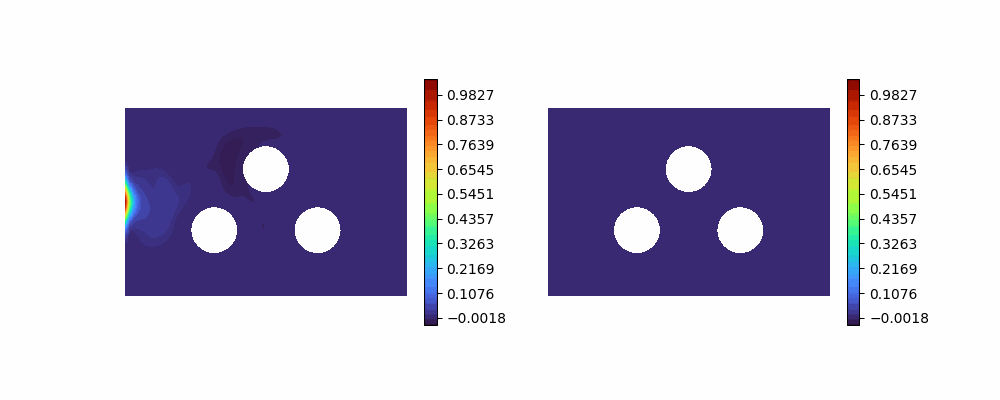

In [45]:
fe.animate((U_same_z, real_group[0]),
    Vh,
    figsize=(10, 4),
    cmap="turbo",
    colorbar=True)

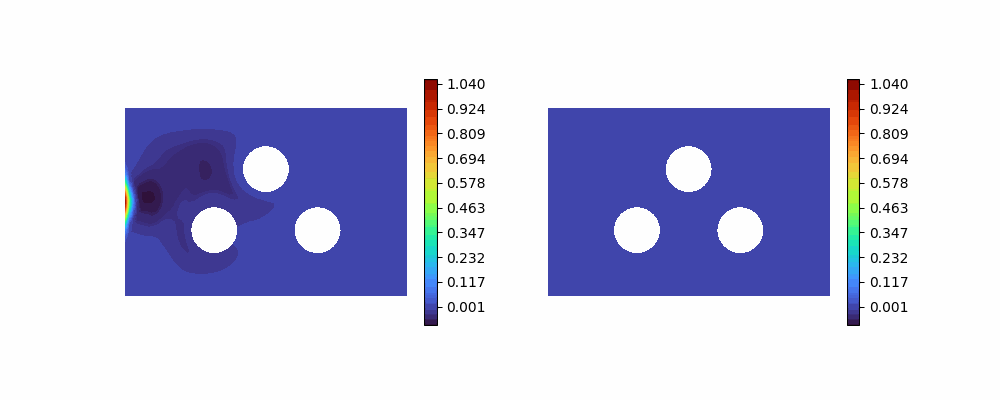

In [46]:
fe.animate((U_ind_z,real_group[0]),
    Vh,
    figsize=(10, 4),
    cmap="turbo",
    colorbar=True)


## 9. Comparison plots

This section is used to qualitatively evaluate the temporal coherence of the generated samples.

A highly variable spatial degree of freedom, called `probe`, is selected, and the real temporal evolution is compared with the generated one.

The goal is to understand whether the model, although trained on individual snapshots, is able to produce a plausible temporal sequence when the same latent variable $z$ is used across all time steps.


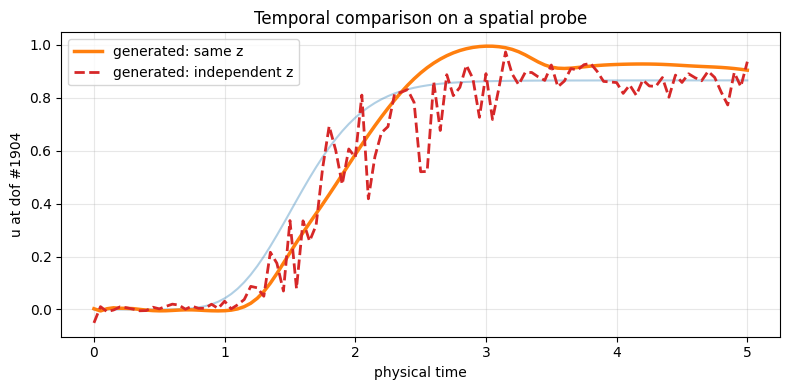

In [47]:
from IPython.display import display

# Selects the spatial degree of freedom with the largest overall variance.
# This makes the comparison more informative, since it focuses on a point, where the solution changes significantly.
probe = int(np.argmax(np.var(trajectories.reshape(-1, Vdim), axis=0)))

fig, ax = plt.subplots(figsize=(8, 4))

for U in real_group:
    ax.plot(times, U[:, probe], color="C0", alpha=0.35)

ax.plot(
    times,
    U_same_z[:, probe],
    color="C1",
    linewidth=2.5,
    label="generated: same z",
)

ax.plot(
    times,
    U_ind_z[:, probe],
    color="C3",
    linewidth=2.0,
    linestyle="--",
    label="generated: independent z",
)

ax.set_xlabel("physical time")
ax.set_ylabel(f"u at dof #{probe}")
ax.set_title("Temporal comparison on a spatial probe")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
display(fig)
plt.close(fig)

The plot compares, on a particularly variable spatial degree of freedom, the real trajectories associated with the selected value of $\mu$ and two trajectories generated by the conditional normalizing flow.

The blue curves represent the real realizations available for the same parameter, while the orange curve is generated using the same latent noise $z$ for all time steps, while the red dashed curve, instead, is obtained by sampling an independent latent noise $z$ at each time.

The trajectory generated with the same $z$ follows the temporal behavior of the real solutions in a fairly regular way: it increases progressively, remains within the range identified by the FOM trajectories for a large part of the time interval, and reaches a final value that is coherent with the real realizations.

This suggests that keeping the latent noise fixed over time helps produce a more continuous and temporally coherent trajectory.

The trajectory generated with independent $z$ values is still able to follow the general trend, but it shows a clear discontinuity around $t \approx 0.45$.
This behavior is expected, because by sampling a different noise vector at each time step, the model generates snapshots conditioned on $(\mu,t)$, but it is not constrained to preserve dynamic coherence between consecutive times.

In the context of the roadmap, this plot clearly shows both the limitation and the usefulness of this approach: the model is still built as a conditional snapshot generator, so it does not impose a true temporal dynamics as a full-trajectory model would.

However, using the same $z$ across all time steps is a simple strategy to introduce a form of temporal correlation among the generated snapshots.

In [ ]:
import matplotlib.pyplot as plt
plt.close("all")